# Modelling Training

In [1]:
%load_ext autoreload
%autoreload 2
from postgresql import get_async_engine
from sqlalchemy import text
from datetime import datetime as dt
import pandas as pd
pd.set_option("display.max_columns", 100)
pd.set_option('display.max_rows', 50)
engine = get_async_engine('test')


In [15]:
from data_repository.features_repository import FeaturesRepository, HeroFeaturesTable, PlayerHeroFeatureTable, TeamFeaturesTable



features_repository = FeaturesRepository(engine)

data_repository.base_repository - Handlers already set up [<StreamHandler stderr (INFO)>, <FileHandler /home/ubuntu/projects/dota2pred/backend/logs/data_repository.base_repository_error.log (ERROR)>]


In [16]:
hero_features = await features_repository.get_all_features_from_table(HeroFeaturesTable)
hero_features

,match_id,hero_picks
0,8266887294,"[Clinkz, Beastmaster, Mars, Zeus, Shadow Demon..."
1,8266885541,"[Medusa, Kunkka, Tiny, Bane, Jakiro, Ancient A..."
2,8266877423,"[Dark Seer, Enigma, Naga Siren, Arc Warden, Sp..."
3,8266874662,"[Slardar, Storm Spirit, Queen of Pain, Luna, B..."
4,8266865035,"[Shadow Shaman, Tiny, Puck, Brewmaster, Phoeni..."
...,...,...
99329,5999283181,"[Enchantress, Timbersaw, Tiny, Wraith King, Or..."
99330,5999249937,"[Void Spirit, Brewmaster, Terrorblade, Snapfir..."
99331,5999214195,"[Centaur Warrunner, Hoodwink, Razor, Grimstrok..."
99332,5999201501,"[Ancient Apparition, Enchantress, Magnus, Embe..."


In [17]:
player_hero_features = await features_repository.get_all_features_from_table(PlayerHeroFeatureTable)
player_hero_features

,player_hero_2_win_rate,match_id,player_hero_4_win_rate,player_hero_129_win_rate,player_hero_131_win_rate,player_hero_3_win_rate,player_hero_0_win_rate,player_hero_1_win_rate,player_hero_128_win_rate,player_hero_130_win_rate,player_hero_132_win_rate
0,0.5,8266887294,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5
1,0.5,8266885541,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5
2,0.5,8266877423,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5
3,0.5,8266874662,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5
4,0.5,8266865035,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5
...,...,...,...,...,...,...,...,...,...,...,...
99328,0.5,5999283181,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5
99329,0.5,5999249937,0.5,0.0,0.5,1.0,0.5,0.5,0.5,0.5,0.5
99330,0.5,5999214195,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5
99331,0.5,5999201501,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5


In [18]:
team_features = await features_repository.get_all_features_from_table(TeamFeaturesTable)
team_features

,radiant_dire_matchup,match_id,radiant_win_rate,dire_win_rate
0,0.5,8266887294,0.5,0.5
1,0.5,8266885541,0.5,0.5
2,0.5,8266877423,0.5,0.5
3,0.5,8266874662,0.5,0.5
4,0.5,8266865035,0.5,0.5
...,...,...,...,...
99329,0.5,5999283181,0.5,0.5
99330,1.0,5999249937,1.0,0.0
99331,0.5,5999214195,0.5,0.5
99332,0.5,5999201501,0.5,0.5


In [19]:
from data_repository.match_repository import MatchRepository, MatchOutcomeTable

match_repository = MatchRepository(engine)

labels = await match_repository.get_all_match_outcome()

labels

,radiant_win,match_id
0,True,8230722475
1,False,8230701740
2,True,8230693148
3,True,8230677659
4,True,8230656847
...,...,...
101611,False,5999283181
101612,False,5999249937
101613,False,5999214195
101614,True,5999201501


In [20]:
dfs = [hero_features, player_hero_features, team_features, labels]

merged_df = dfs[0]
for i in range(1, len(dfs)):
    merged_df = pd.merge(
        merged_df,
        dfs[i],
        on='match_id',
        how='inner'
    )
    
merged_df

,match_id,hero_picks,player_hero_2_win_rate,player_hero_4_win_rate,player_hero_129_win_rate,player_hero_131_win_rate,player_hero_3_win_rate,player_hero_0_win_rate,player_hero_1_win_rate,player_hero_128_win_rate,player_hero_130_win_rate,player_hero_132_win_rate,radiant_dire_matchup,radiant_win_rate,dire_win_rate,radiant_win
0,8230722475,"[Sven, Tiny, Clockwerk, Shadow Demon, Dark See...",0.600000,0.4,0.769231,0.500000,0.75,0.600000,0.550000,0.800000,0.714286,0.80,0.333333,0.5,0.7,True
1,8230701740,"[Ancient Apparition, Magnus, Pudge, Puck, Sven...",0.384615,0.4,0.666667,0.550000,0.70,0.642857,0.500000,0.300000,0.300000,0.50,0.600000,0.7,0.5,False
2,8230693148,"[Tinker, Pangolier, Tiny, Leshrac, Lifestealer...",0.692308,0.5,0.500000,0.833333,1.00,0.777778,0.714286,0.588235,0.600000,0.50,0.625000,0.6,0.6,True
3,8230677659,"[Zeus, Pudge, Wraith King, Sniper, Death Proph...",0.625000,0.6,0.600000,1.000000,0.45,0.250000,0.350000,0.625000,1.000000,0.00,0.350000,0.4,0.8,True
4,8230656847,"[Jakiro, Tidehunter, Lina, Rubick, Tiny, Anti-...",0.400000,0.5,0.350000,0.600000,0.40,0.450000,0.538462,0.384615,0.500000,0.65,0.600000,0.7,0.4,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99320,5999283181,"[Enchantress, Timbersaw, Tiny, Wraith King, Or...",0.500000,0.5,0.500000,0.500000,0.50,0.500000,0.500000,0.500000,0.500000,0.50,0.500000,0.5,0.5,False
99321,5999249937,"[Void Spirit, Brewmaster, Terrorblade, Snapfir...",0.500000,0.5,0.000000,0.500000,1.00,0.500000,0.500000,0.500000,0.500000,0.50,1.000000,1.0,0.0,False
99322,5999214195,"[Centaur Warrunner, Hoodwink, Razor, Grimstrok...",0.500000,0.5,0.500000,0.500000,0.50,0.500000,0.500000,0.500000,0.500000,0.50,0.500000,0.5,0.5,False
99323,5999201501,"[Ancient Apparition, Enchantress, Magnus, Embe...",0.500000,0.5,0.500000,0.500000,0.50,0.500000,0.500000,0.500000,0.500000,0.50,0.500000,0.5,0.5,True


In [22]:
from sklearn.model_selection import train_test_split

features = merged_df.drop(columns=['radiant_win']).copy()
labels = merged_df['radiant_win']

X_train, X_test, y_train, y_test = train_test_split(
    features, 
    labels,
    test_size=0.25,
    random_state=42, 
    shuffle=False
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (74493, 15)
X_test shape: (24832, 15)


In [ ]:
team_player_features = [
    # Player win rates
    'player_hero_0_win_rate',
    'player_hero_1_win_rate',
    'player_hero_2_win_rate',
    'player_hero_3_win_rate',
    'player_hero_4_win_rate',
    'player_hero_128_win_rate',
    'player_hero_129_win_rate',
    'player_hero_130_win_rate',
    'player_hero_131_win_rate',
    'player_hero_132_win_rate',
    # Team features
    'radiant_dire_matchup',
    'radiant_win_rate',
    'dire_win_rate'
]

In [9]:
from inference.feature_preparation import FeaturePreparationService
from data_repository.heroes_repository import HeroesRepository


In [10]:
hero_repository = HeroesRepository(engine)

In [11]:
hero_map = await hero_repository.get_hero_id_map()
hero_list = list(hero_map.values())

In [12]:
MODEL_FEATURE_NAMES = hero_list + team_player_features
MODEL_FEATURE_NAMES

['Anti-Mage',
 'Axe',
 'Bane',
 'Bloodseeker',
 'Crystal Maiden',
 'Drow Ranger',
 'Earthshaker',
 'Juggernaut',
 'Mirana',
 'Morphling',
 'Shadow Fiend',
 'Phantom Lancer',
 'Puck',
 'Pudge',
 'Razor',
 'Sand King',
 'Storm Spirit',
 'Sven',
 'Tiny',
 'Vengeful Spirit',
 'Windranger',
 'Zeus',
 'Kunkka',
 'Lina',
 'Lion',
 'Shadow Shaman',
 'Slardar',
 'Tidehunter',
 'Witch Doctor',
 'Lich',
 'Riki',
 'Enigma',
 'Tinker',
 'Sniper',
 'Necrophos',
 'Warlock',
 'Beastmaster',
 'Queen of Pain',
 'Venomancer',
 'Faceless Void',
 'Wraith King',
 'Death Prophet',
 'Phantom Assassin',
 'Pugna',
 'Templar Assassin',
 'Viper',
 'Luna',
 'Dragon Knight',
 'Dazzle',
 'Clockwerk',
 'Leshrac',
 "Nature's Prophet",
 'Lifestealer',
 'Dark Seer',
 'Clinkz',
 'Omniknight',
 'Enchantress',
 'Huskar',
 'Night Stalker',
 'Broodmother',
 'Bounty Hunter',
 'Weaver',
 'Jakiro',
 'Batrider',
 'Chen',
 'Spectre',
 'Ancient Apparition',
 'Doom',
 'Ursa',
 'Spirit Breaker',
 'Gyrocopter',
 'Alchemist',
 'Invoke

In [25]:
service = FeaturePreparationService(features_repository, hero_repository, MODEL_FEATURE_NAMES)
train_features = await service.get_transformed_features_from_df(
    X_train[hero_features.columns.to_list()], X_train[team_features.columns.to_list()], X_train[player_hero_features.columns.to_list()]
)

test_features = await service.get_transformed_features_from_df(
    X_test[hero_features.columns.to_list()], X_test[team_features.columns.to_list()], X_test[player_hero_features.columns.to_list()]
)

print(f"train_features {train_features.shape}")
print(f"test_features {test_features.shape}")

train_features (74493, 139)
test_features (24832, 139)


In [26]:
train_label = y_train.to_numpy()
test_label = y_test.to_numpy()

print(train_label.shape, test_label.shape)

(74493,) (24832,)


In [27]:
from sklearn.ensemble import RandomForestClassifier 

rf_clf = RandomForestClassifier()
rf_clf.fit(train_features, train_label)




RandomForestClassifier()

In [28]:
from joblib import dump, load

In [29]:
import os
from config import ROOT_DIR

In [30]:
# Persisting the model

output_dir = f"{ROOT_DIR}/models"
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, 'random_forest_model.joblib')
dump(rf_clf, output_path)


['/home/ubuntu/projects/dota2pred/backend/models/random_forest_model.joblib']

## Model Performance Validation

In [31]:
clf = load(output_path)

In [32]:
y_pred = clf.predict(test_features)

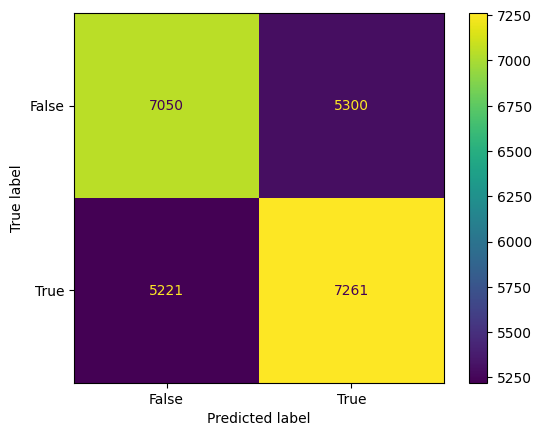

In [33]:
%matplotlib inline
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cm = confusion_matrix(test_label, y_pred, labels=clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot()
plt.show()


In [39]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(test_label, y_pred) 
accuracy

0.5763128221649485

In [38]:
# Prediction with bentoml model service
import requests
import json
import bentoml


In [40]:
from pydantic_models.inference import ModelMetaData, PerformanceMetrics, VersionMetaData 

model_name = 'rf_model'

performance = PerformanceMetrics(
    accuracy=accuracy
)

version_data = VersionMetaData(
    performance_metrics=performance
)

metadata = ModelMetaData(
    name=model_name,
    version="1.0.0",
    trained_date=dt.now(),
    feature_columns=MODEL_FEATURE_NAMES,
    version_metadata=version_data
)

In [41]:
saved_model = bentoml.sklearn.save_model(
    name=model_name,
    model=clf, 
    signatures={'predict':{'batchable':True}},
    metadata=metadata.model_dump()
)

print(f"Model saved: {saved_model}")

Model saved: Model(tag="rf_model:mkwvvtrhbwqcyrlk")


In [37]:
# Wrap the features in another layer with "input_data" key
request_data = {"input_data": {"features": [train_features.tolist()]}}

response = requests.post(
    "http://localhost:3333/predict",
    headers={"Content-Type": "application/json"},
    data=json.dumps(request_data)
)

# Process the response
if response.status_code == 200:
    result = response.json()
    print("Prediction result:", result)
else:
    print(f"Error: {response.status_code}")
    print(response.text)

Error: 500
{"error":"An unexpected error has occurred, please check the server log."}


In [ ]:
result['prediction'][0]